# Pulsed Mode

We test the features of the pulsed mode of Presto for the duration of the meaurement time:
- Generate a quasi-continuous wave pump signal at 8.4 GHz 
- Generate a DC Bias signal 
- Measure raw ADC/digital downconverted time series data

In [10]:
# IMPORTS
# =======
import os
import sys

import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np
from tqdm import tqdm

from presto import lockin, utils, pulsed
from presto.utils import plot_sequence
from presto.hardware import AdcMode, DacMode, AdcFSample, DacFSample

# **Test 1**

### *Create continuous wave pulse and measure it on dummy ports*

In [25]:
# Network settings for Presto Hardware
ADDRESS = '130.237.35.90'   # IP Address
PORT    = 42873             # TCP Port

# Input (ADC) settings
INPUT_PORT = 9          # Dummy loopback port
ADC_ATT = 0.0           # dB, 0.0 to 27.0
INPUT_NCO = 0      # Hz, 0 to 10 GHz
DF = 1e5                # Hz

# Output (DAC) settings
OUTPUT_PORT = 9         # Dummy loopback port
DAC_CURR = 32_000       # μA, 2250 to 40500
AMP = 0.1                # FS, 0.0 to 1.0
FREQ = 0            # Hz, 0 to 500 MHz, intermediate frequency
PHASEI = 0.0            # rad
PHASEQ = PHASEI - np.pi / 2  # rad
OUTPUT_NCO = 8.4e9     # Hz, 0 to 10 GHz

# Configuration for the converter settings
CONVERTER_CONFIGURATION = {
    "address": ADDRESS,
    "port": PORT,
    "ext_ref_clk": False,
    "adc_mode": AdcMode.Direct,
    "adc_fsample": AdcFSample.G2,
    "dac_mode": DacMode.Direct,
    "dac_fsample": DacFSample.G6
} 

In [70]:
with pulsed.Pulsed(
    **CONVERTER_CONFIGURATION
) as pls:
    # Hardware configuration
    # ======================
    pls.hardware.set_dac_current(OUTPUT_PORT, 32_000)  # μA, 2250 to 40500
    pls.hardware.set_inv_sinc(OUTPUT_PORT, 0)
    pls.hardware.set_adc_attenuation(INPUT_PORT, 0.0)  # dB, 0.0 to 27.0

    # Set up measurement time window for data acquisition
    t_meas = 10  # microseconds 
    pls.setup_store(INPUT_PORT, duration=t_meas*1e-6)

    # Set up DC Bias
    # t_init = 0.0
    # DC_BIAS = 1.525       # Set JPA Resonance to 4.2 GHz, taken from latest calibration
    # pls.hardware.set_dc_bias(
    #     bias = DC_BIAS,
    #     port = OUTPUT_PORT
    # )
    # pls.output_dc_bias(
    #     at_time=t_init,
    #     bias = DC_BIAS,
    #     port=OUTPUT_PORT
    # )

    # Set up output pulse waveform (SI units)
    # =======================================
    t_pulse = 2e-6          # seconds
    amp_pulse = 0.5         # FS, 0.0 to 1.0
    freq_pulse = 10e6        # Hz
    t_init = 0              # initial time for pulse generation

    n_samples_pulse = int((t_pulse * pls.get_fs("dac"))) # Number of samples in the pulse
    t_pulse_list = np.linspace(                    # Time array for the pulse
        0, 
        t_pulse, 
        n_samples_pulse, 
        endpoint=False
        )
    wf_pulse = amp_pulse * np.sin(                     # Pulse waveform
        2 * np.pi * freq_pulse * t_pulse_list
        )
    
    # Set up the pulse template at the output port
    pulse_1 = pls.setup_template(OUTPUT_PORT, group=0, template=wf_pulse)

    pls.setup_scale_lut(OUTPUT_PORT, group=0, scales=1.0)

    # Schedule Pulse Output and Data Acquisition
    pls.store(t_init)
    pls.output_pulse(t_init, pulse_1)
    
    # Run sequence
    pls.run(period=t_meas, repeat_count=1, num_averages=1)
    t_arr, data = pls.get_store_data()

ConnectionRefusedError: [Errno 111] Connection refused

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5381/3994472187.py:3: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Time [$\mu$s]")


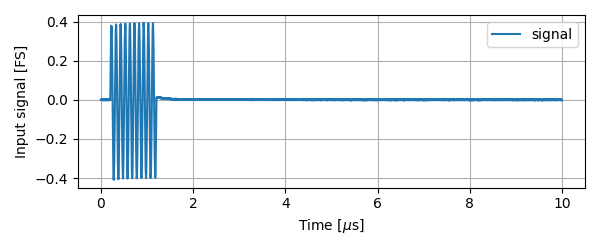

In [66]:
fig, ax = plt.subplots(tight_layout=True, figsize=(6, 2.5))
ax.plot(1e6 * t_arr, data[0, 0, :], label='signal')
ax.set_xlabel("Time [$\mu$s]")
ax.set_ylabel("Input signal [FS]")
ax.grid()
ax.legend()
plt.show()